<a href="https://colab.research.google.com/github/Shreyaupadhyay12/Tomato-Plant-Disease-Detection-Using-Transformer/blob/main/Tomato_Plant_Disease_Detection_Using_Transformer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
w!pip install -q transformers timm albumentations kaggle seaborn ipywidgets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 19.6 MB/s eta 0:00:00


In [ ]:
from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [ ]:
!kaggle datasets download -d emmarex/plantdisease
!unzip -q plantdisease.zip -d data

print("✅ Dataset downloaded successfully!")

Dataset URL: https://www.kaggle.com/datasets/emmarex/plantdisease
License(s): unknown
100% 658M/658M [00:06<00:00, 108MB/s]

✅ Dataset downloaded successfully!


In [ ]:
import os, shutil

source_dir = "data/PlantVillage"
target_dir = "tomato_data"
os.makedirs(target_dir, exist_ok=True)

for folder in os.listdir(source_dir):
    if "Tomato" in folder:
        shutil.copytree(os.path.join(source_dir, folder),
                        os.path.join(target_dir, folder),
                        dirs_exist_ok=True)

print("✅ Tomato data ready")

✅ Tomato data ready


In [ ]:
from sklearn.model_selection import train_test_split

base_dir = "tomato_data"
train_dir = "dataset/train"
val_dir = "dataset/val"

for folder in os.listdir(base_dir):
    os.makedirs(os.path.join(train_dir, folder), exist_ok=True)
    os.makedirs(os.path.join(val_dir, folder), exist_ok=True)

    images = os.listdir(os.path.join(base_dir, folder))
    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    for img in train_imgs:
        shutil.copy(os.path.join(base_dir, folder, img),
                    os.path.join(train_dir, folder, img))

    for img in val_imgs:
        shutil.copy(os.path.join(base_dir, folder, img),
                    os.path.join(val_dir, folder, img))

print("✅ Train-Val split done")

✅ Train-Val split done


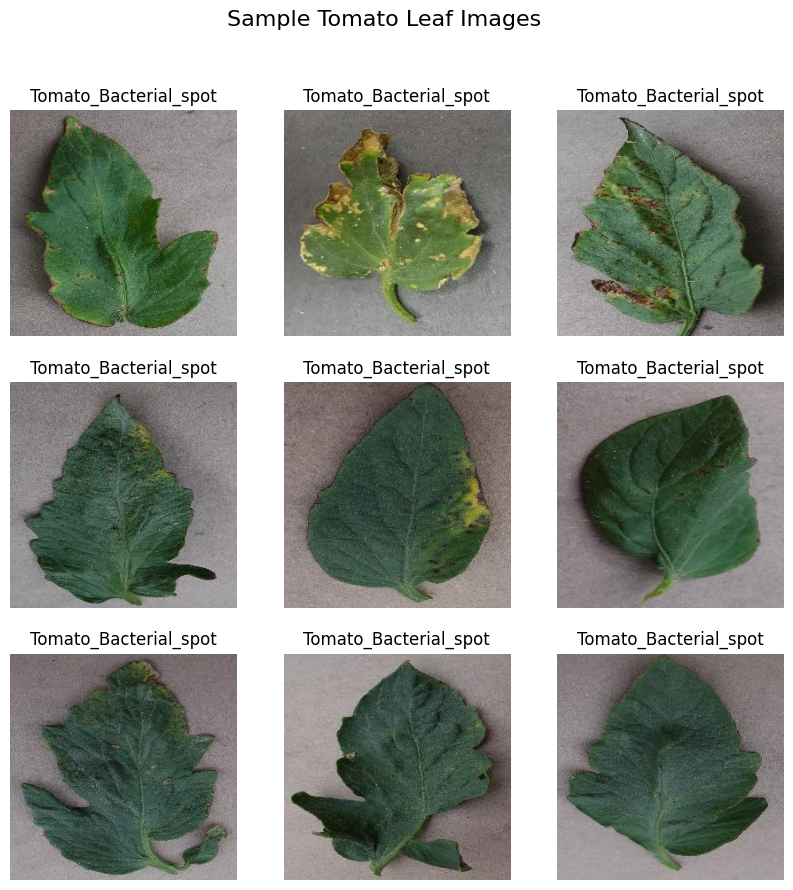

In [ ]:
import matplotlib.pyplot as plt
from torchvision import datasets

sample_data = datasets.ImageFolder(train_dir)

plt.figure(figsize=(10,10))

for i in range(9):
    img, label = sample_data[i]
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.title(sample_data.classes[label])
    plt.axis('off')

plt.suptitle("Sample Tomato Leaf Images", fontsize=16)
plt.show()

In [ ]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [ ]:
from torch.utils.data import DataLoader
from torchvision import datasets

train_data = datasets.ImageFolder(train_dir, transform=train_transform)
val_data = datasets.ImageFolder(val_dir, transform=val_transform)

train_loader = DataLoader(train_data, batch_size=32, shuffle=True, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=32, pin_memory=True)

print("Classes:", train_data.classes)
print(f"Train: {len(train_data)} | Val: {len(val_data)}")

Classes: ['Tomato_Bacterial_spot', 'Tomato_Early_blight', 'Tomato_Late_blight', 'Tomato_Leaf_Mold', 'Tomato_Septoria_leaf_spot', 'Tomato_Spider_mites_Two_spotted_spider_mite', 'Tomato__Target_Spot', 'Tomato__Tomato_YellowLeaf__Curl_Virus', 'Tomato__Tomato_mosaic_virus', 'Tomato_healthy']
Train: 12804 | Val: 3207


In [ ]:
import torch
from transformers import ViTForImageClassification

model = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224",
    num_labels=len(train_data.classes),
    ignore_mismatched_sizes=True
)

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([10])          
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([10, 768])

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


In [ ]:
for name, param in model.named_parameters():
    if ("encoder.layer.11" in name or
        "classifier" in name or
        "layernorm" in name):
        param.requires_grad = True
    else:
        param.requires_grad = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✅ Fine-tuning applied | Trainable params: {trainable:,}")

✅ Fine-tuning applied | Trainable params: 7,130,890


In [ ]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = torch.optim.AdamW([
    {"params": [p for n, p in model.named_parameters()
                if p.requires_grad and "classifier" not in n], "lr": 2e-5},
    {"params": model.classifier.parameters(), "lr": 1e-3}
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=10)

print("✅ Training setup done")

✅ Training setup done


In [ ]:
from sklearn.metrics import accuracy_score
from torch.amp import autocast, GradScaler
import time

train_losses = []
val_accuracies = []
scaler = GradScaler("cuda")

def train_model(epochs=10):
    print("Training Started...\n")
    best_acc = 0.0

    for epoch in range(epochs):
        start_time = time.time()
        print(f"\n🔵 Epoch {epoch+1}/{epochs} ------------------------")

        model.train()
        total_loss = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            with autocast("cuda"):
                outputs = model(images).logits
                loss = criterion(outputs, labels)

            optimizer.zero_grad()
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader)
        train_losses.append(avg_loss)

        scheduler.step()

        model.eval()
        preds, true = [], []

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(device)
                with autocast("cuda"):
                    outputs = model(images).logits
                predictions = torch.argmax(outputs, dim=1).cpu().numpy()
                preds.extend(predictions)
                true.extend(labels.numpy())

        acc = accuracy_score(true, preds)
        val_accuracies.append(acc)

        if acc > best_acc:
            best_acc = acc
            torch.save(model.state_dict(), "best_model.pth")
            print("💾 Best model saved!")

        end_time = time.time()
        print(f"📉 Loss: {avg_loss:.4f}")
        print(f"📈 Accuracy: {acc*100:.2f}%")
        print(f"⏱ Time: {end_time - start_time:.2f} sec")

    print(f"\n✅ Training Completed! Best Accuracy: {best_acc*100:.2f}%")

In [ ]:
train_model(epochs=10)

🚀 Training Started...


🔵 Epoch 1/10 ------------------------
💾 Best model saved!
📉 Loss: 0.9236
📈 Accuracy: 91.99%
⏱ Time: 162.31 sec

🔵 Epoch 2/10 ------------------------
💾 Best model saved!
📉 Loss: 0.7067
📈 Accuracy: 95.70%
⏱ Time: 165.80 sec

🔵 Epoch 3/10 ------------------------
💾 Best model saved!
📉 Loss: 0.6629
📈 Accuracy: 96.07%
⏱ Time: 164.32 sec

🔵 Epoch 4/10 ------------------------
💾 Best model saved!
📉 Loss: 0.6415
📈 Accuracy: 96.98%
⏱ Time: 166.33 sec

🔵 Epoch 5/10 ------------------------
💾 Best model saved!
📉 Loss: 0.6275
📈 Accuracy: 97.54%
⏱ Time: 163.68 sec

🔵 Epoch 6/10 ------------------------
💾 Best model saved!
📉 Loss: 0.6160
📈 Accuracy: 97.57%
⏱ Time: 165.84 sec

🔵 Epoch 7/10 ------------------------
💾 Best model saved!
📉 Loss: 0.6079
📈 Accuracy: 97.66%
⏱ Time: 171.86 sec

🔵 Epoch 8/10 ------------------------
📉 Loss: 0.6032
📈 Accuracy: 97.60%
⏱ Time: 159.91 sec

🔵 Epoch 9/10 ------------------------
📉 Loss: 0.6014
📈 Accuracy: 97.60%
⏱ Time: 160.16 sec

🔵 Epoch 

In [ ]:
# Load best saved model first
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in val_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images).logits
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"✅ Final Validation Accuracy: {accuracy:.2f}%")

✅ Final Validation Accuracy: 98.07%


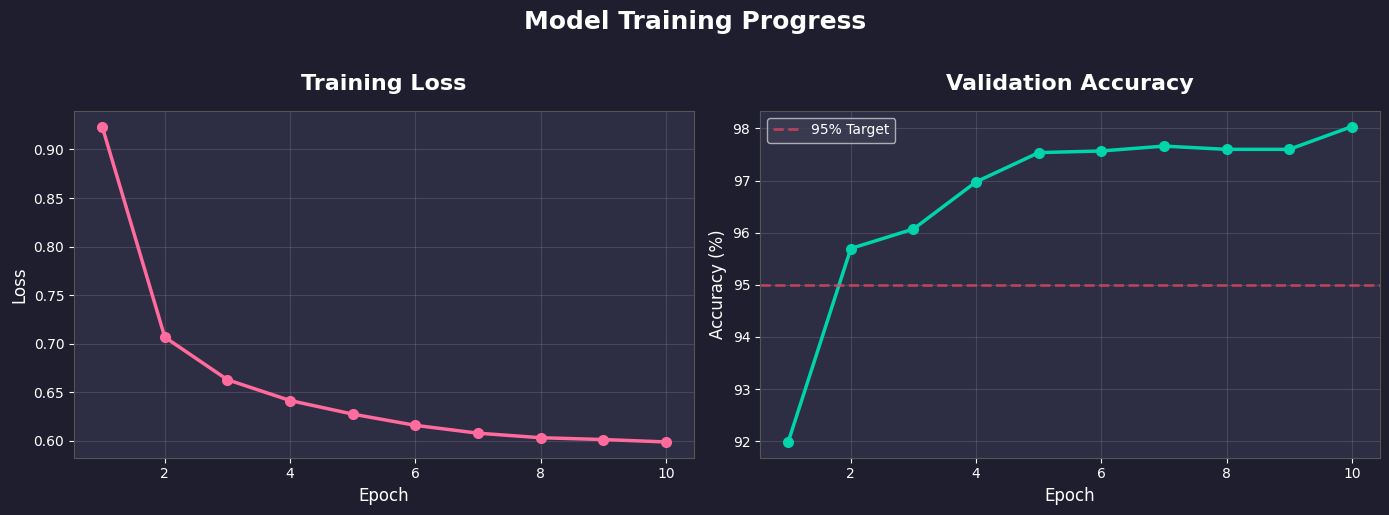

✅ Training graph saved!


In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#1e1e2e')

# Loss plot
ax1.plot(range(1, len(train_losses)+1), train_losses,
         color='#ff6b9d', linewidth=2.5, marker='o', markersize=7)
ax1.set_title('Training Loss', fontsize=16, fontweight='bold', color='white', pad=15)
ax1.set_xlabel('Epoch', fontsize=12, color='white')
ax1.set_ylabel('Loss', fontsize=12, color='white')
ax1.set_facecolor('#2d2d44')
ax1.tick_params(colors='white')
ax1.grid(True, alpha=0.2)
for spine in ax1.spines.values():
    spine.set_edgecolor('#555555')

# Accuracy plot
ax2.plot(range(1, len(val_accuracies)+1), [a*100 for a in val_accuracies],
         color='#00d4aa', linewidth=2.5, marker='o', markersize=7)
ax2.axhline(y=95, color='#e94560', linestyle='--', alpha=0.7,
            linewidth=2, label='95% Target')
ax2.set_title('Validation Accuracy', fontsize=16, fontweight='bold', color='white', pad=15)
ax2.set_xlabel('Epoch', fontsize=12, color='white')
ax2.set_ylabel('Accuracy (%)', fontsize=12, color='white')
ax2.set_facecolor('#2d2d44')
ax2.tick_params(colors='white')
ax2.grid(True, alpha=0.2)
ax2.legend(facecolor='#3d3d54', labelcolor='white')
for spine in ax2.spines.values():
    spine.set_edgecolor('#555555')

plt.suptitle('Model Training Progress', fontsize=18,
             fontweight='bold', color='white', y=1.02)
plt.tight_layout()
plt.savefig('training_progress.png', dpi=150, bbox_inches='tight',
            facecolor='#1e1e2e')
plt.show()
print("✅ Training graph saved!")

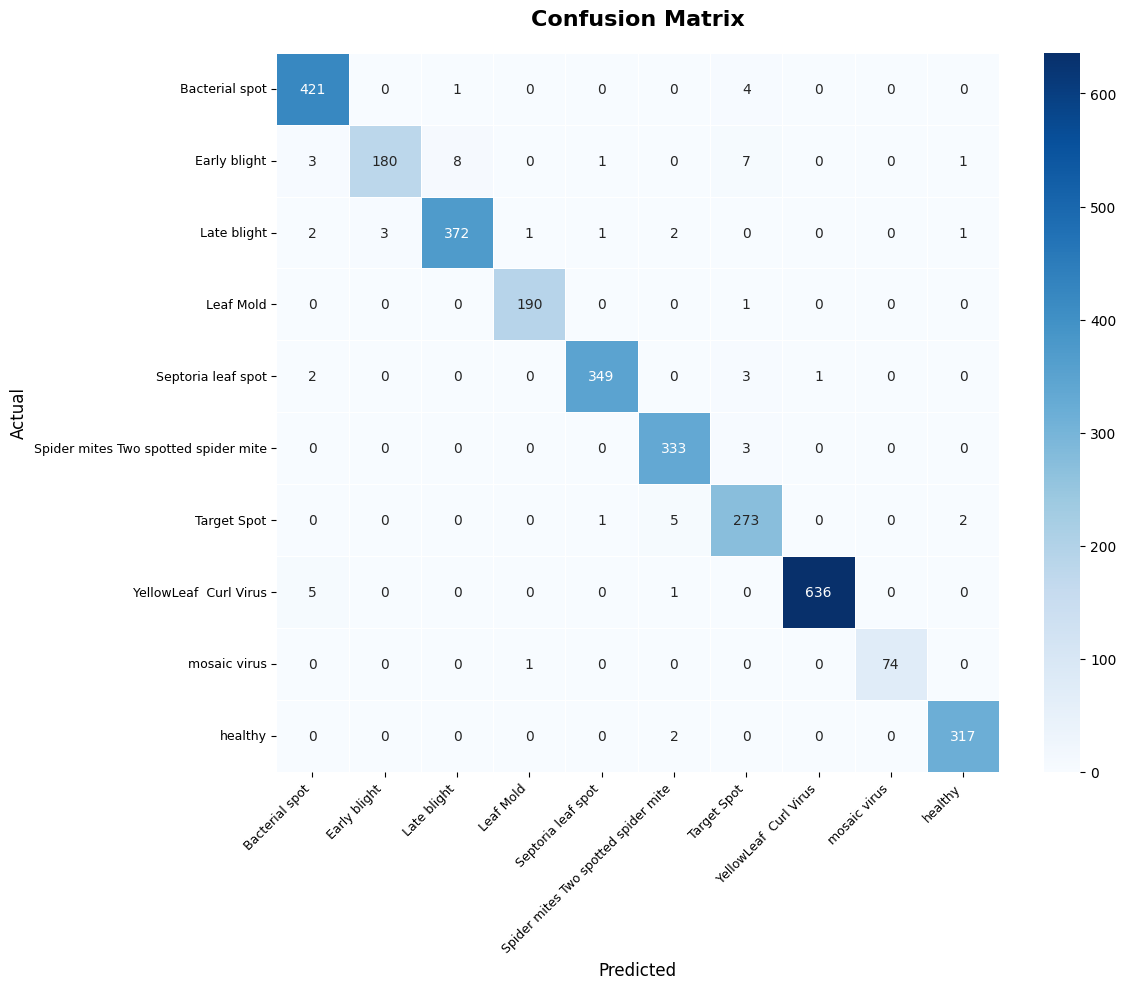

✅ Confusion matrix saved!


In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

model.eval()
all_preds, all_true = [], []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)
        outputs = model(images).logits
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_true.extend(labels.numpy())

# Short class names for display
class_names = [c.replace('Tomato_', '').replace('Tomato__', '').replace('_', ' ')
               for c in train_data.classes]

cm = confusion_matrix(all_true, all_preds)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=0.5)
plt.title('Confusion Matrix', fontsize=16, fontweight='bold', pad=20)
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Confusion matrix saved!")

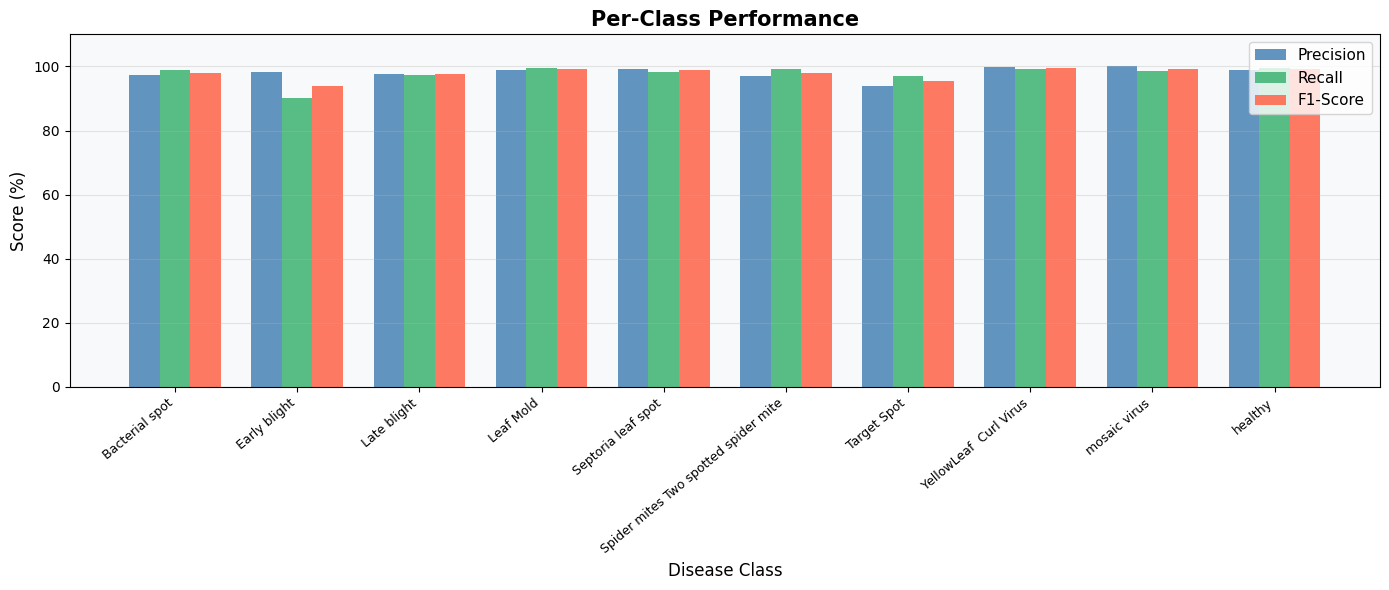

✅ Per-class chart saved!


In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(all_true, all_preds,
                                target_names=class_names,
                                output_dict=True)

classes  = list(report.keys())[:-3]
f1_scores = [report[c]['f1-score'] * 100 for c in classes]
precisions = [report[c]['precision'] * 100 for c in classes]
recalls   = [report[c]['recall'] * 100 for c in classes]

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, precisions, width, label='Precision', color='steelblue',   alpha=0.85)
bars2 = ax.bar(x,          recalls,   width, label='Recall',    color='mediumseagreen', alpha=0.85)
bars3 = ax.bar(x + width,  f1_scores, width, label='F1-Score',  color='tomato',       alpha=0.85)

ax.set_xlabel('Disease Class', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('Per-Class Performance', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=40, ha='right', fontsize=9)
ax.set_ylim(0, 110)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.set_facecolor('#f8f9fa')

plt.tight_layout()
plt.savefig('per_class_performance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Per-class chart saved!")

In [ ]:
from sklearn.metrics import accuracy_score, f1_score

final_acc = accuracy_score(all_true, all_preds) * 100
final_f1  = f1_score(all_true, all_preds, average='weighted') * 100

print("=" * 50)
print("TOMATO DISEASE CLASSIFIER")
print("=" * 50)
print(f"Model      : ViT-Base-Patch16-224")
print(f"Classes    : {len(train_data.classes)}")
print(f"Train imgs : {len(train_data)}")
print(f"Val imgs   : {len(val_data)}")
print(f"Best Acc   : {max(val_accuracies)*100:.2f}%")
print(f"Final Acc  : {final_acc:.2f}%")
print(f"F1-Score   : {final_f1:.2f}%")
print(f"Epochs     : {len(train_losses)}")
print("=" * 50)

TOMATO DISEASE CLASSIFIER
Model      : ViT-Base-Patch16-224
Classes    : 10
Train imgs : 12804
Val imgs   : 3207
Best Acc   : 98.04%
Final Acc  : 98.07%
F1-Score   : 98.06%
Epochs     : 10
